# Data Integrity & Sample Ratio Mismatch (SRM) Audit
## Product Analytics & Data Quality Governance

### Objective
Validate experiment traffic allocation against theoretical split expectations (50/50) using the Chi-Square ($\chi^2$) Goodness-of-Fit test across overall traffic and categorical dimensions (Device, Country).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chisquare, chi2_contingency

# Load raw experiment data
df = pd.read_csv('../data/ab_test_monetization_raw.csv')
print(f"Total Experiment Records Loaded: {len(df):,}")
df.head()

Total Experiment Records Loaded: 50,000


,user_id,variant,device,country,signup_date,converted,revenue
0,USR_000001,control,Web,UK,2026-07-01 00:00:00,0.0,0.0
1,USR_000002,treatment,Android,UK,2026-07-01 00:01:00,0.0,0.0
2,USR_000003,treatment,iOS,US,2026-07-01 00:02:00,0.0,0.0
3,USR_000004,treatment,Android,UK,2026-07-01 00:03:00,0.0,0.0
4,USR_000005,control,iOS,US,2026-07-01 00:04:00,0.0,0.0


### 1. Overall Traffic Allocation & Chi-Square Goodness-of-Fit Test
Hypothesis for SRM:
* $H_0$: Traffic is evenly distributed according to planned 50/50 allocation ratio.
* $H_1$: Significant sample ratio mismatch exists ($p < 0.01$ threshold for SRM).

In [2]:
observed_counts = df['variant'].value_counts().sort_index()
total_traffic = len(df)
expected_counts = [total_traffic * 0.50, total_traffic * 0.50]

# Chi-Square test for goodness of fit
chi2_stat, p_val_srm = chisquare(f_obs=observed_counts, f_exp=expected_counts)

srm_summary = pd.DataFrame({
    'Observed': observed_counts,
    'Expected': expected_counts,
    'Observed Ratio (%)': (observed_counts / total_traffic) * 100,
    'Expected Ratio (%)': [50.0, 50.0]
})

print(srm_summary)
print(f"\nChi-Square Statistic: {chi2_stat:.4f}")
print(f"SRM p-value: {p_val_srm:.4f}")

if p_val_srm < 0.01:
    print("🚨 CRITICAL ALERT: Sample Ratio Mismatch (SRM) detected! Do not proceed to metric analysis.")
else:
    print("✅ PASS: No SRM detected. Traffic allocation matches design ratio.")

           Observed  Expected  Observed Ratio (%)  Expected Ratio (%)
variant                                                              
control       25053   25000.0              50.106                50.0
treatment     24947   25000.0              49.894                50.0

Chi-Square Statistic: 0.2247
SRM p-value: 0.6355
✅ PASS: No SRM detected. Traffic allocation matches design ratio.


### 2. Segment-Level Balance Checks (Device & Geography)
Verify that allocation remains balanced across key user segments.

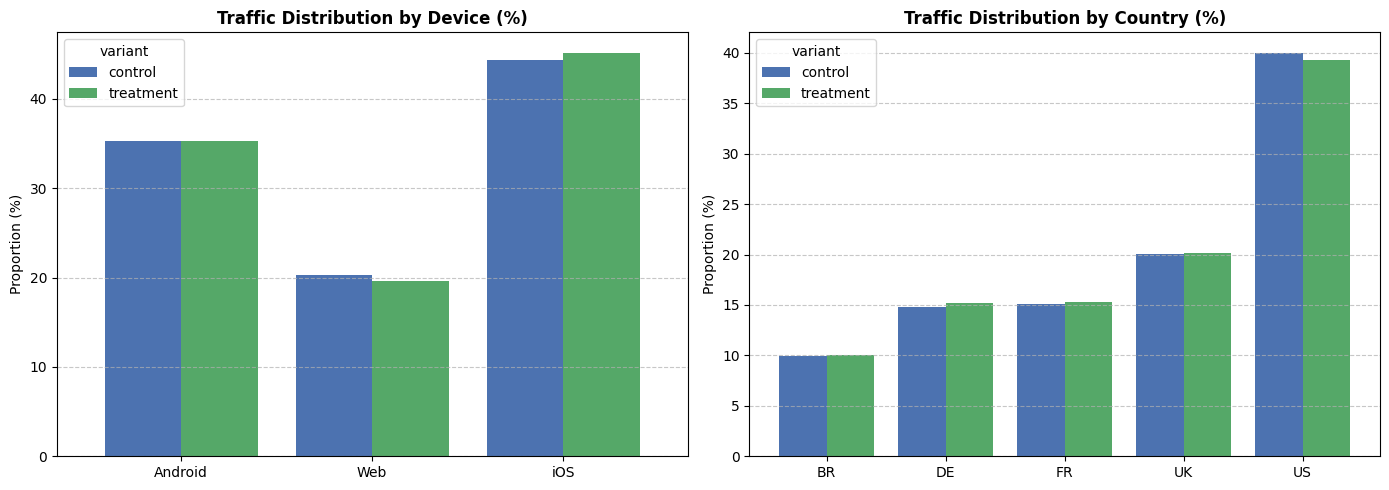

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Device distribution per variant
device_ct = pd.crosstab(df['device'], df['variant'], normalize='columns') * 100
device_ct.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#55A868'], width=0.8)
axes[0].set_title('Traffic Distribution by Device (%)', weight='bold')
axes[0].set_ylabel('Proportion (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Country distribution per variant
country_ct = pd.crosstab(df['country'], df['variant'], normalize='columns') * 100
country_ct.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#55A868'], width=0.8)
axes[1].set_title('Traffic Distribution by Country (%)', weight='bold')
axes[1].set_ylabel('Proportion (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('../assets/srm_segment_checks.png', dpi=300)
plt.show()

### 3. Missing Values & Unique Identifier Integrity

In [4]:
null_counts = df.isnull().sum()
unique_users = df['user_id'].nunique()

print(f"Total Records: {len(df):,}")
print(f"Unique User IDs: {unique_users:,}")
print(f"Duplicate User IDs: {len(df) - unique_users}")
print("\nMissing Value Audit:")
print(null_counts)

Total Records: 50,000
Unique User IDs: 50,000
Duplicate User IDs: 0

Missing Value Audit:
user_id        0
variant        0
device         0
country        0
signup_date    0
converted      0
revenue        0
dtype: int64
